# IMDB Reviews - Evaluation & Comparison of Models

Evaluate the trained models on a sample dataset and compare the results

In [60]:
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import sys
import joblib

PROJ_ROOT = Path().cwd().resolve().parent
DATA_PATH = PROJ_ROOT / "data" / "sample_imdb_tiny.csv"
MODELS_DIR = PROJ_ROOT / "models"
REPORTS_DIR = PROJ_ROOT / "reports" / "metrics"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str((PROJ_ROOT / "src").resolve()))
from data_utils import basic_clean

In [64]:
# Load a small sample of the dataset for evaluation
df = pd.read_csv(DATA_PATH)
df['text'] = df['text'].map(basic_clean)
N = min(500, len(df))
sample = df.sample(n=N, random_state=42).reset_index(drop=True)
sample.head()

,text,label
0,movie rollercoaster emotions plot twists kept ...,positive
1,waste time good acting predictable plot,negative
2,fell asleep halfway it's boring badly written,negative
3,absolutely loved movie performances outstandin...,positive
4,watch balances humor drama perfectly,positive


In [19]:
available_models = {}
for p in MODELS_DIR.glob("*_tfidf_model.joblib"):
    try:
        pipe = joblib.load(p)
        available_models[p.stem] = ("tfidf", pipe)
    except Exception as e:
        print("Could not load", p, "->", e)

list(available_models.keys())

['lr_tfidf_model', 'nb_tfidf_model', 'svm_tfidf_model']

In [11]:
def evaluate_predictions(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {"model": model_name, "accuracy": acc, "macro_precision": p, "macro_recall": r, "macro_f1": f1, "report": rep}

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=['negative','positive'])
    fig = plt.figure()
    im = plt.imshow(cm, interpolation='nearest')
    plt.title(title); plt.colorbar(im)
    plt.xticks([0,1], ['negative','positive']); plt.yticks([0,1], ['negative','positive'])
    for i in range(2):
        for j in range(2):
            plt.text(j,i,cm[i,j],ha='center',va='center')
    plt.xlabel('Predicted'); plt.ylabel('True')
    fig.tight_layout(); plt.show()

Evaluating: lr_tfidf_model (tfidf)


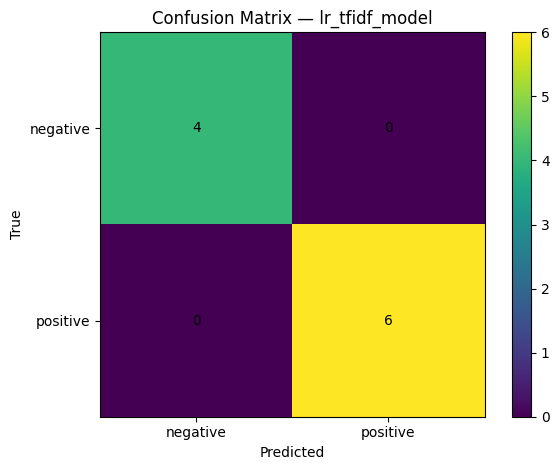

Evaluating: nb_tfidf_model (tfidf)


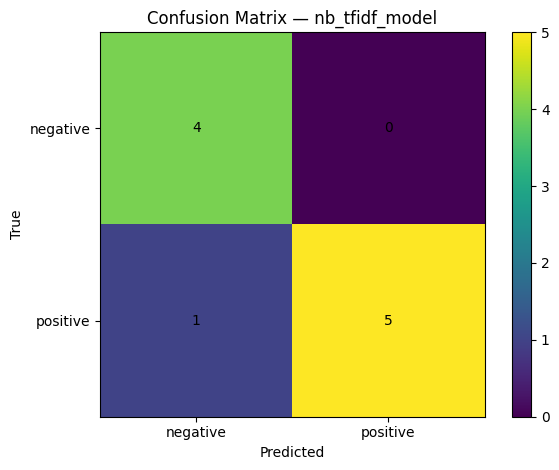

Evaluating: svm_tfidf_model (tfidf)


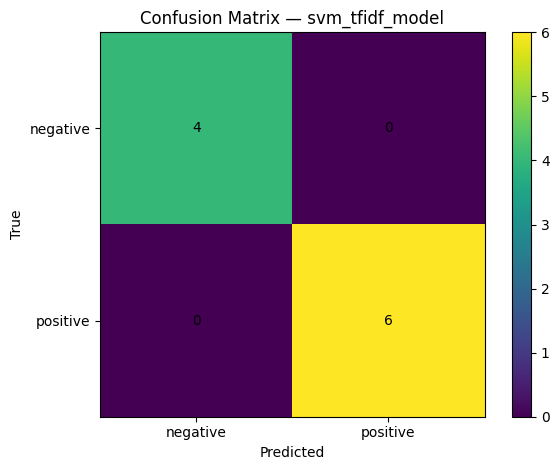

In [65]:
results = []
y_true = sample['label'].tolist()

for name, (kind, obj) in available_models.items():
    print(f"Evaluating: {name} ({kind})")
    pipe = obj
    y_pred = pipe.predict(sample['text'].tolist()).tolist()
    res = evaluate_predictions(y_true, y_pred, name)
    results.append(res)
    plot_confusion_matrix(y_true, y_pred, f"Confusion Matrix — {name}")

In [66]:
pd.DataFrame([{k:v for k,v in r.items() if k!='report'} for r in results]).sort_values('macro_f1', ascending=False)

,model,accuracy,macro_precision,macro_recall,macro_f1
0,lr_tfidf_model,1.0,1.0,1.000000,1.00000
2,svm_tfidf_model,1.0,1.0,1.000000,1.00000
1,nb_tfidf_model,0.9,0.9,0.916667,0.89899


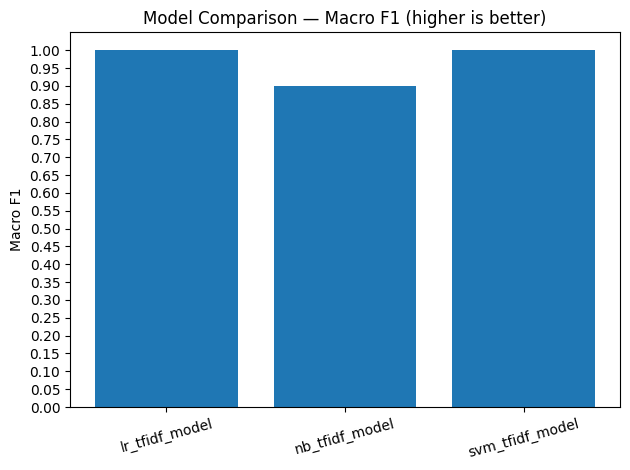

In [67]:
# Comparison bar chart (Macro F1)
if results:
    names = [r['model'] for r in results]
    f1s   = [r['macro_f1'] for r in results]
    import numpy as np, matplotlib.pyplot as plt
    plt.figure()
    xs = np.arange(len(names))
    plt.bar(xs, f1s)
    plt.xticks(xs, names, rotation=15)
    plt.yticks(np.arange(0.0, 1.01, 0.05))
    plt.ylabel("Macro F1")
    plt.title("Model Comparison — Macro F1 (higher is better)")
    plt.tight_layout()
    plt.show()
else:
    print("No models found to evaluate.")